# 02 — Линейная регрессия на Advertising

Главный ноутбук недели. Здесь мы пройдём весь цикл реального ML-проекта на простом примере: данные → EDA → split → fit → predict → метрики → интерпретация → полиномиальные фичи → Pipeline → сохранение модели.

К этому моменту ты уже знаком с pandas/numpy. Здесь мы соберём всё вместе в полный ML-цикл.

## Setup и загрузка данных

Что мы будем вызывать впервые:

- `LinearRegression()` из `sklearn.linear_model` — модель линейной регрессии.
- `model.fit(X, y)` — обучение (внутри решает аналитическую систему уравнений).
- `model.predict(X)` — предсказание.
- `model.coef_, model.intercept_` — выученные веса и свободный член.
- `mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error`   — четыре главные метрики регрессии.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
import joblib

RANDOM_STATE = 42
df = pd.read_csv('data/Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## О датасете

В демо используем **Advertising.csv** — 200 рекламных кампаний.

| Колонка | Тип | Описание |
|---|---|---|
| `TV` | float | Бюджет на TV-рекламу, тыс. долл. |
| `radio` | float | Бюджет на радио, тыс. долл. |
| `newspaper` | float | Бюджет на газеты, тыс. долл. |
| `sales` | float | Продажи продукта, тыс. единиц (целевая переменная) |

Размер: 200 строк × 4 колонки.

Бизнес-задача: построить модель, которая по бюджетам трёх каналов предсказывает продажи и подсказывает CMO, в какой канал вкладывать дополнительный доллар.


Цель: предсказать `sales` (продажи) по трём бюджетам — `TV`, `radio`, `newspaper`. Это **классическая задача регрессии для маркетинга**: «куда вкладывать деньги — на TV или в газеты?».

## Краткий EDA перед обучением

Перед любой моделью полезно ещё раз глянуть на данные — особенно если переключился из другого ноутбука. Это занимает 30 секунд и может спасти от часа отладки.

In [2]:
print(f'Размер: {df.shape}')
print(f'Пропусков: {df.isna().sum().sum()}')
df.describe().round(2)

Размер: (200, 4)
Пропусков: 0


,TV,radio,newspaper,sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


### pairplot: все scatter-плоты попарно одной командой

Сейчас построим `pairplot` — это сетка scatter-графиков для всех пар колонок плюс гистограмма по диагонали. Лучший способ за один взгляд увидеть структуру данных.

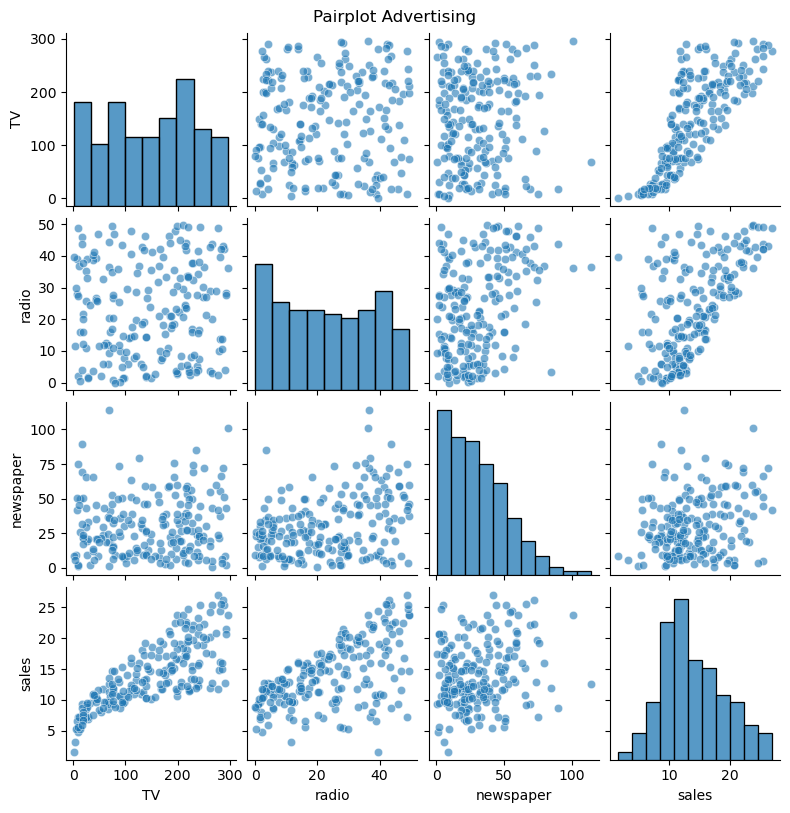

In [3]:
sns.pairplot(df, height=2.0, plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot Advertising', y=1.01)
plt.show()

На графиках видно:

- В нижнем ряду (`sales` по y) есть линейная зависимость от TV (тренд почти прямой),   средняя от radio, слабая от newspaper.
- Между TV/radio/newspaper никаких сильных связей нет (мультиколлинеарность отсутствует).
- Распределения по диагонали показывают, что `sales` имеет лёгкий правый скос.

Это значит, что **простой линрег должен сработать неплохо**, и нет причин выкидывать ни одну из фичей.

---

## Train/test split

Разбиваем 80/20. `random_state=42` для воспроизводимости

In [4]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'train: {X_train.shape}, test: {X_test.shape}')

train: (160, 3), test: (40, 3)


---

## Обучаем baseline линрег

**Что мы будем вызывать:** `LinearRegression().fit(X_train, y_train)` — это базовый sklearn-API. Под капотом sklearn решает систему уравнений МНК через SVD-разложение (быстрее и стабильнее, чем учебная формула с `(XᵀX)⁻¹`).

Учебники часто показывают `np.linalg.inv(X.T @ X) @ X.T @ y` — **в продакшене так не делают**, потому что обращение матрицы численно нестабильно при коррелированных фичах. Используй `LinearRegression()` всегда.

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
print('Модель обучена.')

Модель обучена.


Всё, модель обучена. У линрега это **доли секунды** даже на миллионах строк — одна из причин, почему линрег по сей день жив в проде, особенно в задачах real-time скоринга, где нужно отвечать за миллисекунды.

### Что выучила модель

После обучения модель — это **набор чисел**: `coef_` (веса при фичах) и `intercept_` (свободный член). Этого достаточно, чтобы делать предсказания по формуле `y = w1·TV + w2·radio + w3·newspaper + b`.

In [6]:
coefs = pd.Series(model.coef_, index=X.columns).round(4)
intercept = round(model.intercept_, 4)
print('Коэффициенты:')
print(coefs)
print(f'\nIntercept (b): {intercept}')

Коэффициенты:
TV           0.0447
radio        0.1892
newspaper    0.0028
dtype: float64

Intercept (b): 2.9791


**Бизнес-интерпретация коэффициентов** (главная ценность линрега — он объясним):

- `TV ≈ 0.045` — увеличение TV-бюджета на $1K даёт +45 единиц продаж.
- `radio ≈ 0.19` — каждый $1K на radio даёт +190 единиц.
- `newspaper ≈ 0.003` — газеты почти бесполезны (близко к нулю).
- `intercept ≈ 2.9` — базовый уровень продаж, если бы все бюджеты были 0.

**Маркетинговый вывод:** деньги стоит вкладывать в radio и TV. Газеты можно урезать.

---

## Предсказания и метрики

Получаем предсказания на test и считаем все 4 главные метрики регрессии.

In [7]:
y_pred = model.predict(X_test)
print('Первые 5 предсказаний:', y_pred[:5].round(2))
print('Реальные значения:    ', y_test.values[:5])

Первые 5 предсказаний: [16.41 20.89 21.55 10.61 22.11]
Реальные значения:     [16.9 22.4 21.4  7.3 24.7]


Близко! Чтобы понять, насколько — нужны метрики.

In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MAE:  {mae:.3f}   (средняя абс. ошибка в K единиц продаж)')
print(f'RMSE: {rmse:.3f}   (то же, но штрафует большие ошибки сильнее)')
print(f'MAPE: {mape:.3%}  (средняя ошибка в процентах от истинного значения)')
print(f'R²:   {r2:.3f}    (доля объяснённой дисперсии, 1 = идеал)')

MAE:  1.461   (средняя абс. ошибка в K единиц продаж)
RMSE: 1.782   (то же, но штрафует большие ошибки сильнее)
MAPE: 15.199%  (средняя ошибка в процентах от истинного значения)
R²:   0.899    (доля объяснённой дисперсии, 1 = идеал)


**Как читать эти числа:**

- MAE 1.46 = «в среднем ошибаемся на 1460 единиц при истинных продажах ~14000».
- RMSE 1.78 > MAE, разница не катастрофическая — значит больших отдельных промахов нет.
- MAPE ~12% — стандартный язык бизнеса. «Мы предсказываем продажи с точностью 88%».
- R² 0.90 — модель объясняет 90% дисперсии продаж. Это **очень хорошо** для маркетинга.

Подробнее про каждую метрику — в одном из заданий по теме метрик регрессии.

---

## Графики качества

Числа — числами, но на графиках видно паттерны, которые метрики прячут.

### 1. y_true vs y_pred (диагональ-плот)

Идеальные предсказания лежали бы на диагонали `y = x`. Чем ближе точки к ней — тем лучше модель.

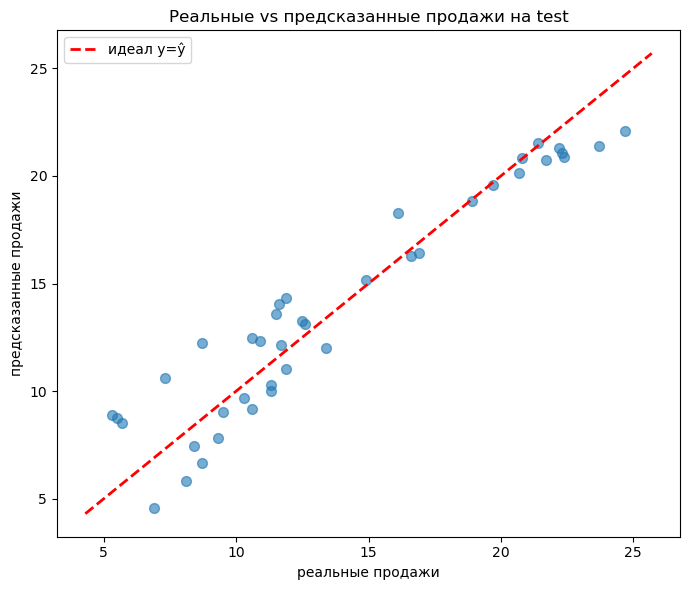

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.6, s=50)
lims = [y_test.min() - 1, y_test.max() + 1]
ax.plot(lims, lims, 'r--', lw=2, label='идеал y=ŷ')
ax.set_xlabel('реальные продажи')
ax.set_ylabel('предсказанные продажи')
ax.set_title('Реальные vs предсказанные продажи на test')
ax.legend()
plt.tight_layout()
plt.show()

На графике видно: точки группируются вокруг диагонали, но при больших значениях (>20K) разброс заметно растёт. Это означает, что **модель хуже предсказывает крупные кампании** — там линейности уже не хватает, нужны полиномиальные фичи или более сложная модель.

### 2. График остатков (residuals)

**Остаток** = `y_true - y_pred` для каждого объекта. Если модель честная — остатки должны быть случайным шумом вокруг нуля. Если виден паттерн (тренд, изгиб) — модель что-то не уловила.

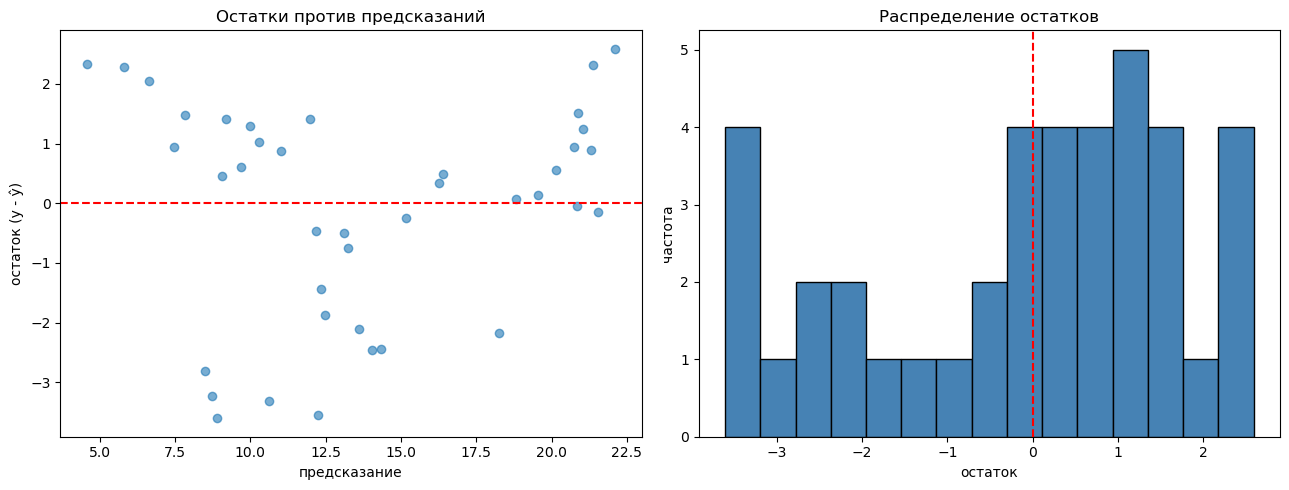

Среднее остатков: -0.098
std остатков:     1.779


In [10]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Слева: остатки vs предсказание.
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('предсказание')
axes[0].set_ylabel('остаток (y - ŷ)')
axes[0].set_title('Остатки против предсказаний')

# Справа: гистограмма остатков (должна быть похожа на нормальное распределение).
axes[1].hist(residuals, bins=15, edgecolor='black', color='steelblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('остаток')
axes[1].set_ylabel('частота')
axes[1].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

print(f'Среднее остатков: {residuals.mean():.3f}')
print(f'std остатков:     {residuals.std():.3f}')

На графиках видно:

- **Слева:** при больших предсказаниях остатки разъезжаются (гетероскедастичность).   Это и есть «плохо предсказываем большие кампании».
- **Справа:** распределение остатков более-менее симметричное вокруг нуля,   слегка похоже на нормальное — нет систематического смещения.

Среднее остатков ≈ 0 и std ≈ RMSE — это согласованность модели.

---

## Полиномиальные фичи

Видим в графике остатков, что линейности не хватает на больших значениях. Простой трюк: добавить в фичи квадраты и попарные произведения. Это позволит линрегу учить кривые, не меняя самого алгоритма.

**Что мы будем вызывать:** `PolynomialFeatures(degree=N, include_bias=False)` из `sklearn.preprocessing`. Преобразует `[x1, x2, x3]` в `[x1, x2, x3, x1², x1·x2, x1·x3, x2², x2·x3, x3²]` для degree=2.

In [11]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f'было фичей: {X_train.shape[1]}')
print(f'стало фичей: {X_train_poly.shape[1]}')
print(f'имена новых фичей: {poly.get_feature_names_out().tolist()}')

было фичей: 3
стало фичей: 9
имена новых фичей: ['TV', 'radio', 'newspaper', 'TV^2', 'TV radio', 'TV newspaper', 'radio^2', 'radio newspaper', 'newspaper^2']


**Важно про fit_transform vs transform:**

- `fit_transform(X_train)` — изучает структуру (какие комбинации создавать) и применяет.
- `transform(X_test)` — только применяет, **никогда не делай fit на test** —   это утечка данных.

Те же три фичи дали 9 новых. Обучим на них линрег.

In [12]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)
print(f'Polynomial degree=2:')
print(f'  RMSE: {rmse_poly:.3f}  (было {rmse:.3f})')
print(f'  R²:   {r2_poly:.3f}    (было {r2:.3f})')

Polynomial degree=2:
  RMSE: 0.643  (было 1.782)
  R²:   0.987    (было 0.899)


Заметное улучшение: RMSE упал, R² вырос. Это значит, что в данных есть нелинейные эффекты — например, **взаимодействие TV·radio** (когда обе кампании идут одновременно, эффект больше суммы).

---

## Pipeline: всё в одну цепочку

Когда у тебя есть несколько шагов препроцессинга + модель, удобно собрать их в `Pipeline`. Преимущества:

1. Один `fit` обучает всю цепочку.
2. Один `predict` применяет препроцессинг + предсказание.
3. Pipeline нельзя забыть применить — никакой ручной работы с `transform`.
4. Pipeline можно сохранить как одну модель.

**Что мы будем вызывать:** `Pipeline([('step1', obj1), ('step2', obj2)])` или `make_pipeline(obj1, obj2)` (короткая форма, имена сама подставит).

In [13]:
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),  # масштабируем фичи (полезно для регуляризации позже)
    ('linreg', LinearRegression()),
])

pipe.fit(X_train, y_train)
rmse_pipe = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
print(f'Pipeline RMSE: {rmse_pipe:.3f}')

Pipeline RMSE: 0.643


Тот же результат, что в ручном варианте, но кода в 3 раза меньше. И — важно — когда `pipe` будет в проде в FastAPI, мы вызываем `pipe.predict(new_data)` и автоматически получаем поли-фичи, нормализацию, и предсказание.

---

## Сравниваем модели через cross-validation

Один train/test даёт одно число. Чтобы быть уверенными, что наш polynomial(2) действительно лучше baseline-линрега — гоним k-fold.

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'baseline': LinearRegression(),
    'poly degree=2': make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        LinearRegression(),
    ),
    'poly degree=3': make_pipeline(
        PolynomialFeatures(degree=3, include_bias=False),
        LinearRegression(),
    ),
}

results = []
for name, m in models.items():
    scores = -cross_val_score(
        m, X, y, cv=kf, scoring='neg_root_mean_squared_error'
    )
    results.append({
        'model': name,
        'rmse_mean': scores.mean(),
        'rmse_std': scores.std(),
    })

comparison = pd.DataFrame(results).round(3)
comparison

,model,rmse_mean,rmse_std
0,baseline,1.706,0.236
1,poly degree=2,0.640,0.160
2,poly degree=3,0.569,0.106


Polynomial(2) — оптимум: лучшее среднее, маленький std. Polynomial(3) уже похож на переобучение (mean ниже, но std раздулся — нестабильно).

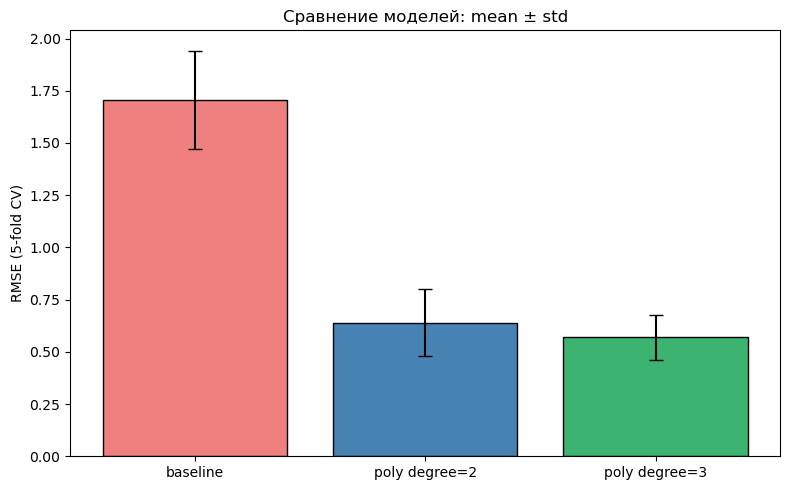

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(comparison['model'], comparison['rmse_mean'], yerr=comparison['rmse_std'],
       capsize=5, color=['lightcoral', 'steelblue', 'mediumseagreen'], edgecolor='black')
ax.set_ylabel('RMSE (5-fold CV)')
ax.set_title('Сравнение моделей: mean ± std')
plt.tight_layout()
plt.show()

На bar chart с error bars видна **значимость разницы**. Если error bars двух моделей сильно перекрываются — разница незначима. У нас polynomial(2) явно лучше baseline.

---

## Сохранение и загрузка модели

Когда модель готова — сохраняем её на диск, чтобы потом загрузить в FastAPI-сервис.

**Что мы будем вызывать:**

- `joblib.dump(model, 'model.pkl')` — сохранить модель в файл.
- `joblib.load('model.pkl')` — загрузить модель из файла.

In [16]:
# Тренируем финальную модель на ВСЕХ данных (после того, как уже выбрали по CV).
final_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linreg', LinearRegression()),
])
final_pipe.fit(X, y)

# Сохраняем.
joblib.dump(final_pipe, '/tmp/advertising_model.pkl')
print('Модель сохранена в /tmp/advertising_model.pkl')

Модель сохранена в /tmp/advertising_model.pkl


In [17]:
# Загружаем — это то, что делает FastAPI на старте.
loaded = joblib.load('/tmp/advertising_model.pkl')

# Эмулируем запрос: новая кампания TV=200, radio=40, newspaper=20.
new_campaign = pd.DataFrame([[200, 40, 20]], columns=['TV', 'radio', 'newspaper'])
prediction = loaded.predict(new_campaign)[0]
print(f'Прогноз продаж для новой кампании: {prediction:.2f}K единиц')

Прогноз продаж для новой кампании: 20.92K единиц


Это и есть **минимальный production-цикл линрега**: обучили → сохранили pickle → FastAPI загружает на старте → отвечает за миллисекунды.

---

## Что мы сделали

1. Загрузили данные и сделали EDA (`pairplot`).
2. Обучили `LinearRegression`, посмотрели коэффициенты, дали бизнес-интерпретацию.
3. Посчитали 4 метрики (MAE, RMSE, MAPE, R²) и научились их читать.
4. Построили графики качества (y_true vs y_pred + остатки).
5. Расширили фичи через `PolynomialFeatures` и улучшили модель.
6. Собрали всё в `Pipeline`.
7. Сравнили модели через k-fold CV.
8. Сохранили финальную модель на диск (`joblib`).

Дальше — `02_linreg_sklearn_practice.ipynb` (12 связанных упражнений). В solution смотри только если застрял!